In [ ]:
# IPL Big Data Analysis using Dask

In [29]:
import dask.dataframe as dd
import matplotlib.pyplot as plt

In [30]:
df = dd.read_csv("../data/ipl.csv", dtype='object')
df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,<NA>,0,1,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,<NA>,0,1,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,<NA>,0,1,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,<NA>,0,2,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,<NA>,0,3,0,"('BB McCullum', 'SC Ganguly')",<NA>,False


In [14]:
import dask.dataframe as dd

df = dd.read_csv("../data/ipl.csv", dtype='object')

df.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,<NA>,0,1,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,<NA>,0,1,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,<NA>,0,1,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,<NA>,0,2,0,"('BB McCullum', 'SC Ganguly')",<NA>,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,<NA>,0,3,0,"('BB McCullum', 'SC Ganguly')",<NA>,False


In [31]:
# Convert required columns
df["runs_total"] = dd.to_numeric(df["runs_total"], errors="coerce")
df["runs_batter"] = dd.to_numeric(df["runs_batter"], errors="coerce")
df["match_id"] = dd.to_numeric(df["match_id"], errors="coerce")
df["season"] = dd.to_numeric(df["season"], errors="coerce")

In [ ]:
#Analysis

In [32]:
top_teams = df.groupby("batting_team")["runs_total"] \
    .sum().compute().sort_values(ascending=False)

top_teams.head(10)

batting_team
Mumbai Indians                 45088
Kolkata Knight Riders          41333
Chennai Super Kings            41070
Royal Challengers Bangalore    37692
Rajasthan Royals               37361
Sunrisers Hyderabad            31590
Kings XI Punjab                30064
Delhi Daredevils               24296
Delhi Capitals                 17400
Punjab Kings                   12798
Name: runs_total, dtype: Int64

In [33]:
top_batsmen = df.groupby("batter")["runs_batter"] \
    .sum().compute().sort_values(ascending=False)

top_batsmen.head(10)

batter
V Kohli           8671
RG Sharma         7048
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5235
AB de Villiers    5181
AM Rahane         5032
CH Gayle          4997
Name: runs_batter, dtype: Int64

In [34]:
top_bowlers = df[df["wicket_kind"].notnull()] \
    .groupby("bowler")["wicket_kind"] \
    .count().compute().sort_values(ascending=False)

top_bowlers.head(10)

bowler
YS Chahal     229
B Kumar       213
SP Narine     212
DJ Bravo      207
R Ashwin      205
JJ Bumrah     203
PP Chawla     201
SL Malinga    188
A Mishra      183
RA Jadeja     179
Name: wicket_kind, dtype: int64

In [24]:
top_teams = df.groupby("batting_team")["runs_total"] \
    .sum().compute().sort_values(ascending=False)

top_teams.head(10)

batting_team
Mumbai Indians                 45088.0
Kolkata Knight Riders          41333.0
Chennai Super Kings            41070.0
Royal Challengers Bangalore    37692.0
Rajasthan Royals               37361.0
Sunrisers Hyderabad            31590.0
Kings XI Punjab                30064.0
Delhi Daredevils               24296.0
Delhi Capitals                 17400.0
Punjab Kings                   12798.0
Name: runs_total, dtype: float64

In [35]:
matches_per_season = df.groupby("season")["match_id"] \
    .nunique().compute().sort_index()

matches_per_season

season
2009    57
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2021    60
2022    74
2023    74
2024    71
2025    74
Name: match_id, dtype: int64

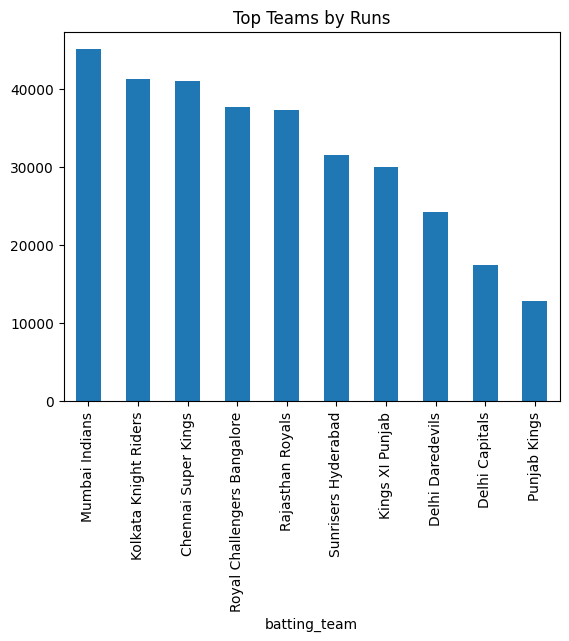

In [36]:
top_teams.head(10).plot(kind='bar')
plt.title("Top Teams by Runs")
plt.show()

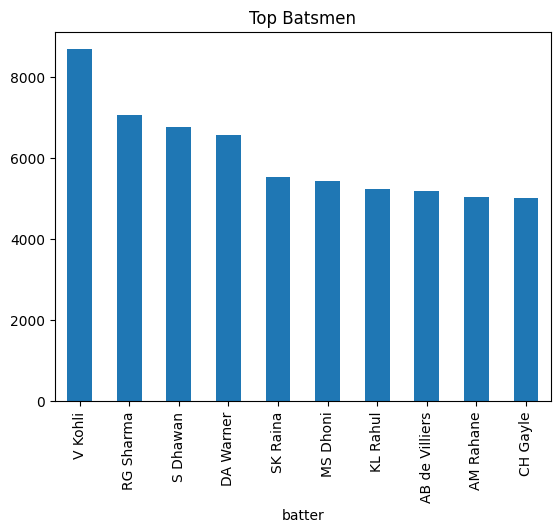

In [37]:
top_batsmen.head(10).plot(kind='bar')
plt.title("Top Batsmen")
plt.show()

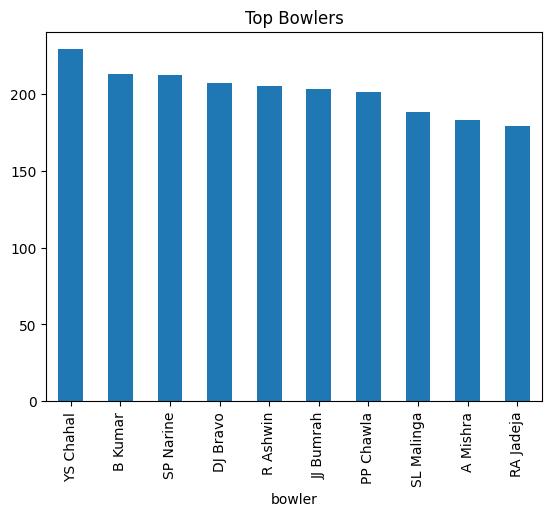

In [38]:
top_bowlers.head(10).plot(kind='bar')
plt.title("Top Bowlers")
plt.show()

In [ ]:
## Insights

"""
1. Teams like Mumbai Indians and Chennai Super Kings have scored the highest total runs.
2. Certain batsmen consistently dominate across multiple seasons.
3. Bowlers with higher wicket counts are key match influencers.
4. The number of matches has increased over seasons, showing IPL growth."""